# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


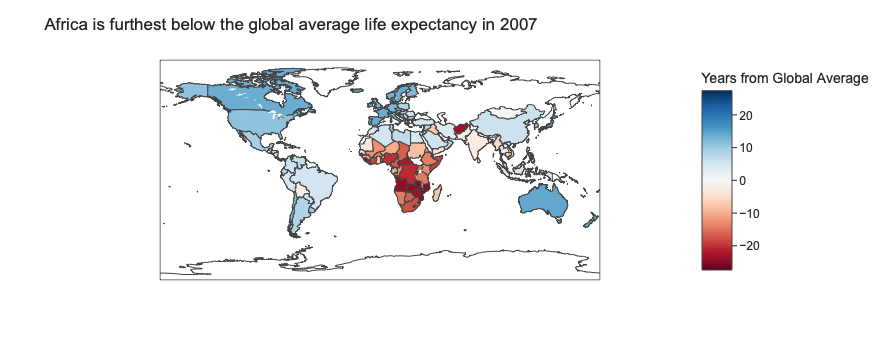

In [3]:
# Task 1
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

# Load Gapminder data for 2007
gm = px.data.gapminder()
gm_2007 = gm[gm['year'] == 2007].copy()

# Global average life expectancy
global_avg = gm_2007['lifeExp'].mean()

# Deviation from global average
gm_2007['lifeExp_dev'] = gm_2007['lifeExp'] - global_avg

# Find region furthest below average
region_avg = (
    gm_2007.groupby('continent')['lifeExp_dev']
    .mean()
    .sort_values()
)

lowest_region = region_avg.index[0]

# Choropleth map
fig = px.choropleth(
    gm_2007,
    locations='iso_alpha',
    color='lifeExp_dev',
    hover_name='country',
    hover_data={
        'lifeExp': ':.1f',
        'lifeExp_dev': ':.1f',
        'iso_alpha': False
    },
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0
)

fig.update_layout(
    title=f'Africa is furthest below the global average life expectancy in 2007',
    template='simple_white',
    font=dict(family='Arial'),
    coloraxis_colorbar_title='Years from Global Average'
)

fig.show()



### Design Decisions

**Chart type chosen:** px.choropleth

I used `px.choropleth` because the Gapminder dataset already contains country ISO codes and the goal is to compare values across countries rather than show detailed street-level geography.

**Colour scale chosen:** Diverging (RdBu)

A diverging scale is appropriate because the data shows deviation from the global average. Values above zero are above average and values below zero are below average, making zero the natural midpoint.

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

### GeoJSON source

US States GeoJSON from GitHub:
https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json

### Chart type chosen and reason

I used px.choropleth because it works directly with GeoJSON boundary files and does not require a Mapbox basemap.

### Colour scale chosen and reason

I used a sequential colour scale (Blues) because the values increase from low to high and there is no meaningful midpoint.


{'name': 'Alabama', 'density': 94.65}


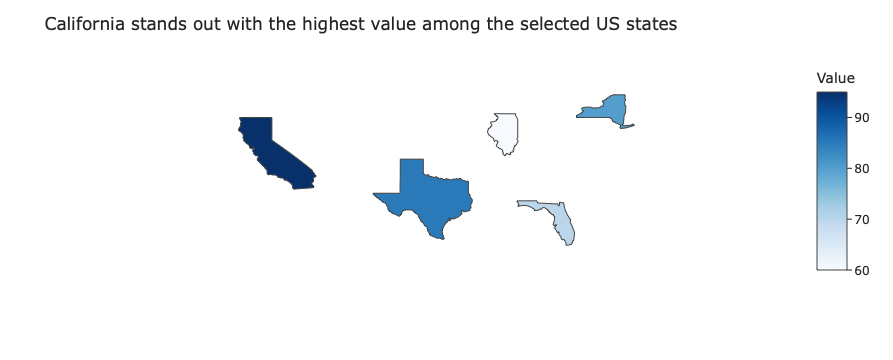

In [5]:
# Task 2
# YOUR CODE HERE
import pandas as pd
import plotly.express as px
import json
from urllib.request import urlopen

# Load GeoJSON
with urlopen(
    'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'
) as response:
    us_states = json.load(response)

# Inspect properties
print(us_states['features'][0]['properties'])

# Create dataset
df_map = pd.DataFrame({
    'State': [
        'California',
        'Texas',
        'Florida',
        'New York',
        'Illinois'
    ],
    'Value': [
        95,
        85,
        70,
        80,
        60
    ]
})

# Choropleth
fig = px.choropleth(
    df_map,
    geojson=us_states,
    locations='State',
    featureidkey='properties.name',
    color='Value',
    color_continuous_scale='Blues'
)

fig.update_geos(
    fitbounds='locations',
    visible=False
)

fig.update_layout(
    title='California stands out with the highest value among the selected US states',
    template='simple_white'
)

fig.show()
